# Day 32 — Naive Bayes, Probability Foundations & Gaussian Mixture Models (GMM)

## Topics Covered
- Probability vs Likelihood vs Odds vs Prior Probability
- Bayes Theorem
- Bernoulli Naive Bayes
- Multinomial Naive Bayes
- Gaussian Mixture Model (GMM)
- GMM vs KMeans
- Naive Bayes vs PCA
- Practical Use Cases
- Advantages & Limitations
- Tasks + Mini Projects



# Learning Objectives

By the end of this notebook, you will understand:

✅ How probability concepts are used inside Machine Learning  
✅ Why Naive Bayes is called "Naive"  
✅ Difference between Bernoulli and Multinomial Naive Bayes  
✅ How GMM performs soft clustering  
✅ Difference between GMM and PCA  
✅ Real-world BFSI and AI applications  
✅ Advantages and limitations of probabilistic models  

---

# Why This Topic Matters

Probability-based Machine Learning models are everywhere:

- Gmail Spam Detection
- Fraud Detection
- Credit Risk Analysis
- Sentiment Analysis
- Recommendation Systems
- Customer Segmentation

This notebook builds the theoretical foundation behind probabilistic AI systems.



# 1. Probability Foundations

## What is Probability?

Probability measures the chance of an event occurring.

Example:
- Probability of rain = 0.8
- Probability of spam email = 0.95

Range:
- 0 → Impossible
- 1 → Certain

---

# Probability vs Likelihood vs Odds vs Prior Probability

| Concept | Meaning | Example |
|---|---|---|
| Probability | Chance of event happening | Probability of spam |
| Likelihood | How likely data fits a model | Likelihood of words given spam |
| Odds | Ratio of success vs failure | 4:1 odds |
| Prior Probability | Initial belief before evidence | Spam frequency in dataset |

---

# Probability

P(A)

Meaning:
Chance of event A happening.

Example:
Probability that an email is spam.

---

# Likelihood

P(Data | Model)

Meaning:
How well observed data fits a model.

Example:
How likely these words appear if email is spam.

---

# Odds

Odds = Probability of success / Probability of failure

Example:
If probability = 0.8

Odds = 0.8 / 0.2 = 4

Meaning:
4 successful outcomes for every 1 failure.

---

# Prior Probability

Prior probability is the initial belief before seeing evidence.

Example:
Suppose:
- 70% emails are normal
- 30% emails are spam

Then:
Prior probability of spam = 0.3



# 2. Bayes Theorem

Bayes theorem updates probability after seeing evidence.

## Formula

P(A|B) = (P(B|A) × P(A)) / P(B)

Where:

| Term | Meaning |
|---|---|
| P(A|B) | Posterior Probability |
| P(B|A) | Likelihood |
| P(A) | Prior Probability |
| P(B) | Evidence |

---

# Real Example

Suppose:
- 1% people have disease
- Test accuracy = 95%

Bayes theorem helps estimate:

"What is probability patient truly has disease after positive test?"

This is heavily used in:
- Medical diagnosis
- Fraud detection
- Credit risk
- AI recommendation systems



# 3. Naive Bayes

## What is Naive Bayes?

Naive Bayes is a probabilistic classification algorithm based on Bayes Theorem.

It assumes:
"All features are independent of each other"

This assumption is called the:
### Naive Assumption

---

# Why is it Powerful?

Even though independence assumption is unrealistic,
Naive Bayes performs surprisingly well on:

- Text classification
- NLP
- Spam detection
- Sentiment analysis

---

# Core Formula

Posterior ∝ Likelihood × Prior



# 4. Bernoulli Naive Bayes

## What is Bernoulli Naive Bayes?

Used when features are binary.

Features contain:
- 0 or 1
- Yes or No
- True or False

---

# Example

| Word | Present? |
|---|---|
| Free | 1 |
| Offer | 1 |
| Meeting | 0 |

Used in:
- Spam detection
- Binary text representation

---

# Advantages

✅ Simple  
✅ Fast  
✅ Works well for binary text features  

---

# Limitations

❌ Loses frequency information  
❌ Less effective for long documents  



# 5. Multinomial Naive Bayes

## What is Multinomial Naive Bayes?

Used for count-based features.

Instead of checking:
"Is word present?"

It checks:
"How many times word appears?"

---

# Example

| Word | Count |
|---|---|
| Free | 4 |
| Offer | 2 |
| Win | 5 |

---

# Common Use Cases

- Email spam filtering
- News classification
- Sentiment analysis
- NLP pipelines

---

# Advantages

✅ Excellent for NLP  
✅ Fast training  
✅ Works well on sparse data  

---

# Limitations

❌ Independence assumption unrealistic  
❌ Weak on highly correlated features  



# 6. Bernoulli vs Multinomial Naive Bayes — Practical Code


In [1]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

texts = [
    "win money now",
    "free lottery ticket",
    "meeting at office",
    "project discussion tomorrow",
    "claim your free reward",
    "team lunch tomorrow"
]

labels = [1,1,0,0,1,0]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(texts)

X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.3, random_state=42
)

multi_nb = MultinomialNB()
multi_nb.fit(X_train, y_train)

pred_multi = multi_nb.predict(X_test)

print("Multinomial NB Accuracy:", accuracy_score(y_test, pred_multi))

bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(X_train, y_train)

pred_bern = bernoulli_nb.predict(X_test)

print("Bernoulli NB Accuracy:", accuracy_score(y_test, pred_bern))


Multinomial NB Accuracy: 0.5
Bernoulli NB Accuracy: 0.0



# 7. Gaussian Mixture Model (GMM)

## What is GMM?

Gaussian Mixture Model is a probabilistic clustering algorithm.

Unlike KMeans:
- KMeans assigns hard clusters
- GMM assigns probabilities

---

# Soft Clustering

Example:

| Customer | Cluster A | Cluster B |
|---|---|---|
| User 1 | 80% | 20% |

Meaning:
User partially belongs to multiple clusters.

---

# Why GMM is Powerful

Real-world data is often overlapping.

GMM handles:
- Complex distributions
- Elliptical clusters
- Uncertainty

better than KMeans.

---

# Key Concept

Data is assumed to come from multiple Gaussian distributions.



# 8. GMM Clustering Example


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


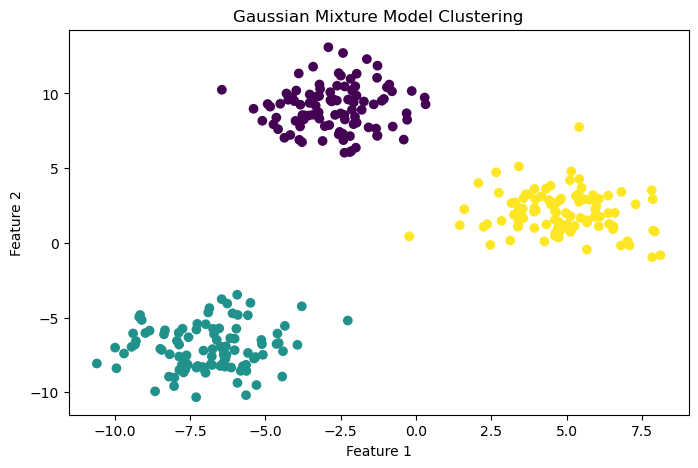

In [2]:

from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.5,
    random_state=42
)

gmm = GaussianMixture(n_components=3)

gmm.fit(X)

labels = gmm.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



# 9. GMM vs KMeans vs PCA

| Feature | GMM | KMeans | PCA |
|---|---|---|---|
| Type | Probabilistic clustering | Distance clustering | Dimensionality reduction |
| Cluster Membership | Soft | Hard | No clustering |
| Shape Handling | Flexible | Circular | Not clustering |
| Main Goal | Model distributions | Group points | Reduce dimensions |
| Output | Probability clusters | Fixed clusters | Principal components |

---

# Important Insight

PCA does NOT classify or cluster.

PCA only:
- Compresses features
- Removes redundancy
- Preserves variance

Naive Bayes predicts classes.
GMM finds probabilistic clusters.



# 10. Practical Industry Use Cases

# Naive Bayes in BFSI

## Fraud Detection
Detect suspicious transaction patterns.

## Credit Risk
Estimate probability of loan default.

## Email Filtering
Detect phishing emails.

---

# GMM in BFSI

## Customer Segmentation
Group customers by spending behavior.

## Risk Modeling
Model uncertain financial distributions.

## Anomaly Detection
Detect unusual transaction patterns.

---

# PCA + GMM Pipeline

Common real-world pipeline:

1. PCA → reduce dimensions
2. GMM → cluster customers
3. Naive Bayes → classify future users



# 11. Tasks for Practice

## Beginner Tasks

1. Train Bernoulli Naive Bayes on spam dataset
2. Compare Bernoulli vs Multinomial accuracy
3. Visualize GMM clusters
4. Compare KMeans vs GMM outputs

---

## Intermediate Tasks

1. Apply PCA before GMM
2. Build sentiment classifier
3. Tune number of GMM components

---

## Advanced Tasks

1. Build fraud detection pipeline
2. Create customer segmentation dashboard
3. Compare Naive Bayes with Logistic Regression



# 12. Mini Project — AI Spam Detection System

## Problem Statement

Build a spam detection system using:
- Multinomial Naive Bayes

---

# Workflow

1. Collect email dataset
2. Text preprocessing
3. Convert text to vectors
4. Train Naive Bayes
5. Evaluate accuracy

---

# Business Impact

Helps:
- Banks
- Email providers
- Enterprises

reduce phishing and fraud attacks.



# 13. Final Summary

## Key Takeaways

### Probability Concepts
- Probability = chance
- Likelihood = data fit
- Prior = initial belief
- Odds = success/failure ratio

---

### Naive Bayes
- Classification algorithm
- Fast and lightweight
- Excellent for NLP

---

### GMM
- Probabilistic clustering
- Handles overlapping clusters
- More flexible than KMeans

---

### PCA
- Dimensionality reduction
- Compression technique
- Often used before clustering

---

# Final Industry Insight

Modern AI systems often combine:

PCA + GMM + Naive Bayes

to create scalable intelligent pipelines.
